<a href="https://colab.research.google.com/github/silvjunu/devowel/blob/main/devowel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeVowel

**Exploring Vowel-Reduced Vocal Timbre**

DeVowel explores whether vowel identity can be reduced from a sustained human voice while preserving speaker-specific vocal characteristics.

## Core Question

Can vowel identity be reduced while preserving the characteristic timbre of the original voice?

## Current Goal — v0.1

The first prototype will:

1. load a sustained vowel audio file,
2. inspect its waveform and spectrum,
3. estimate its spectral envelope,
4. modify the envelope to reduce vowel-specific characteristics,
5. resynthesize and listen to the processed sound.

The first version focuses on a sustained `/a/` vowel from a single speaker.

## 0. Session Setup

This section prepares the temporary Colab environment.

Because the Colab runtime can reset between sessions, every session should begin by running the setup cells from the top.

### Libraries used

- `numpy`: numerical arrays and audio signal calculations
- `scipy`: signal processing tools
- `matplotlib`: waveform and spectrum visualization
- `soundfile`: reading and writing WAV audio

At this stage, we only check that the required libraries are available. We will install additional packages only when they become necessary.

### Google Drive

Audio recordings are stored in Google Drive because the Colab runtime is temporary.

The notebook code is versioned with GitHub, while private or larger audio files are kept separately in Google Drive.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [1]:
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import soundfile as sf

print("Environment ready.")
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("SoundFile:", sf.__version__)

Environment ready.
NumPy: 2.1.3
SciPy: 1.16.3
Matplotlib: 3.10.0
SoundFile: 0.14.0


In [9]:
from pathlib import Path

project_dir = Path("/content/drive/MyDrive/devowel")
audio_dir = project_dir / "audio"

raw_dir = audio_dir / "raw"
wav_dir = audio_dir / "wav"

wav_dir.mkdir(parents=True, exist_ok=True)

print("Raw folder:", raw_dir)
print("WAV folder:", wav_dir)
print("Raw exists:", raw_dir.exists())
print("WAV exists:", wav_dir.exists())

Raw folder: /content/drive/MyDrive/devowel/audio/raw
WAV folder: /content/drive/MyDrive/devowel/audio/wav
Raw exists: True
WAV exists: True


### Audio Format Conversion

The original recordings were captured as M4A files.

The original files are preserved in `audio/raw/`.
For analysis, they are decoded into WAV files and stored separately in `audio/wav/`.

Converting M4A to WAV does not restore information lost during compression.
WAV is used because uncompressed PCM audio is easier and more predictable to analyze.

In [11]:
import subprocess

for input_path in m4a_files:
  output_path = wav_dir / f"{input_path.stem}.wav"

  command = [
    "ffmpeg",
    "-y",
    "-i", str(input_path),
    "-ac", "1",
    "-ar", "44100",
    str(output_path),
  ]

  subprocess.run(
    command,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    check=True,
  )

  print(f"{input_path.name} -> {output_path.name}")

a_01.m4a -> a_01.wav
a_02.m4a -> a_02.wav
e_01.m4a -> e_01.wav
e_02.m4a -> e_02.wav
i_01.m4a -> i_01.wav
i_02.m4a -> i_02.wav
o_01.m4a -> o_01.wav
o_02.m4a -> o_02.wav
u_01.m4a -> u_01.wav
u_02.m4a -> u_02.wav


## 1. Audio Quality Check

Before spectral analysis, we first check whether the recording itself is suitable for analysis.

For one WAV file, we inspect:

- sample rate and channel shape
- duration
- peak amplitude
- RMS level
- possible clipping
- waveform shape
- the actual recorded sound

This step is not yet vowel or formant analysis.
Its purpose is only to confirm that the input recording is technically usable and contains a stable sustained-vowel region.

File: a_01.wav
Sample rate: 44100 Hz
Shape: (238023,)
Duration: 5.40 s
Peak amplitude: 0.7024
RMS: 0.0912
Samples near clipping: 0


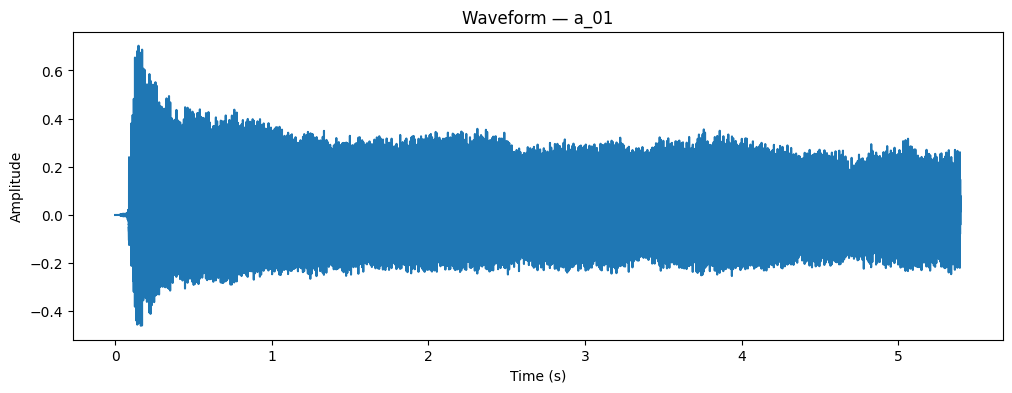

In [22]:
def inspect_audio(audio_path):
  wave, sr = sf.read(audio_path)

  duration = len(wave) / sr
  peak_amp = np.max(np.abs(wave))
  rms = np.sqrt(np.mean(wave ** 2))

  clip_threshold = 0.999
  clip_count = np.sum(np.abs(wave) >= clip_threshold)

  print(f"File: {audio_path.name}")
  print(f"Sample rate: {sr} Hz")
  print(f"Shape: {wave.shape}")
  print(f"Duration: {duration:.2f} s")
  print(f"Peak amplitude: {peak_amp:.4f}")
  print(f"RMS: {rms:.4f}")
  print(f"Samples near clipping: {clip_count}")

  display(Audio(wave, rate=sr))

  time = np.arange(len(wave)) / sr

  plt.figure(figsize=(12, 4))
  plt.plot(time, wave)
  plt.xlabel("Time (s)")
  plt.ylabel("Amplitude")
  plt.title(f"Waveform — {audio_path.stem}")
  plt.show()

  return wave, sr


audio_path = wav_dir / "a_01.wav"
wave, sr = inspect_audio(audio_path)

## 2. Dataset Quality Check

Before comparing vowels, we inspect all recordings under the same criteria.

For each file, we compare:

- duration
- peak amplitude
- RMS level
- possible clipping

The goal is to detect recordings that differ unusually in length or level before spectral analysis.

RMS values are especially useful here as relative measurements across recordings rather than as absolute quality scores.

In [23]:
import pandas as pd

qc_rows = []

for audio_path in wav_files:
  wave_temp, sr_temp = sf.read(audio_path)

  duration = len(wave_temp) / sr_temp
  peak_amp = np.max(np.abs(wave_temp))
  rms = np.sqrt(np.mean(wave_temp ** 2))
  clip_count = np.sum(np.abs(wave_temp) >= 0.999)

  qc_rows.append({
    "file": audio_path.name,
    "duration_s": duration,
    "peak_amp": peak_amp,
    "rms": rms,
    "clip_count": clip_count,
  })

qc_df = pd.DataFrame(qc_rows)

qc_df = qc_df.round({
  "duration_s": 2,
  "peak_amp": 4,
  "rms": 4,
})

display(qc_df)

,file,duration_s,peak_amp,rms,clip_count
0,a_01.wav,5.40,0.7024,0.0912,0
1,a_02.wav,6.25,0.4359,0.0776,0
2,e_01.wav,6.23,0.3087,0.0673,0
3,e_02.wav,5.44,0.2625,0.0560,0
4,i_01.wav,5.40,0.1791,0.0659,0
5,i_02.wav,6.08,0.1623,0.0532,0
6,o_01.wav,6.17,0.2318,0.0579,0
7,o_02.wav,5.50,0.1819,0.0476,0
8,u_01.wav,6.57,0.2397,0.0675,0
9,u_02.wav,6.21,0.1647,0.0480,0


## 3. Fundamental Frequency Check

The recordings were intended to use the same pitch across all vowels.

Before comparing vowel spectra, we estimate the fundamental frequency (`f0`) of each recording to check how closely the pitches match.

To reduce the influence of the attack and release of each note, only the central 2 seconds are analyzed.

The signal is divided into short frames, and `f0` is estimated from the autocorrelation of each frame.

For each recording, we inspect:

- median `f0`
- variation of `f0` over time
- pitch difference from the median pitch of the whole dataset, measured in cents

Small differences are expected because a human voice is not perfectly stationary.

In [24]:
from scipy.signal import correlate

def estimate_frame_f0(frame, sr, fmin=70, fmax=500):
  frame = frame - np.mean(frame)
  frame = frame * np.hanning(len(frame))

  autocorr = correlate(frame, frame, mode="full", method="fft")
  autocorr = autocorr[len(autocorr) // 2:]

  min_lag = int(sr / fmax)
  max_lag = int(sr / fmin)

  search = autocorr[min_lag:max_lag + 1]
  peak_lag = np.argmax(search) + min_lag

  return sr / peak_lag


def estimate_audio_f0(wave, sr, center_duration=2.0):
  center_sample = len(wave) // 2
  half_length = int(center_duration * sr / 2)

  start = max(0, center_sample - half_length)
  end = min(len(wave), center_sample + half_length)

  stable_wave = wave[start:end]

  frame_length = int(0.05 * sr)
  hop_length = int(0.02 * sr)

  f0_values = []

  for start_idx in range(0, len(stable_wave) - frame_length, hop_length):
    frame = stable_wave[start_idx:start_idx + frame_length]

    if np.sqrt(np.mean(frame ** 2)) < 0.01:
      continue

    f0 = estimate_frame_f0(frame, sr)
    f0_values.append(f0)

  return np.array(f0_values)


pitch_rows = []

for audio_path in wav_files:
  wave_temp, sr_temp = sf.read(audio_path)

  f0_values = estimate_audio_f0(wave_temp, sr_temp)

  pitch_rows.append({
    "file": audio_path.name,
    "f0_median_hz": np.median(f0_values),
    "f0_std_hz": np.std(f0_values),
  })

pitch_df = pd.DataFrame(pitch_rows)

dataset_f0 = np.median(pitch_df["f0_median_hz"])

pitch_df["cents_from_median"] = (
  1200 * np.log2(pitch_df["f0_median_hz"] / dataset_f0)
)

pitch_df = pitch_df.round({
  "f0_median_hz": 2,
  "f0_std_hz": 2,
  "cents_from_median": 1,
})

display(pitch_df)

print(f"Dataset median f0: {dataset_f0:.2f} Hz")

,file,f0_median_hz,f0_std_hz,cents_from_median
0,a_01.wav,127.46,0.56,0.0
1,a_02.wav,126.72,0.63,-10.0
2,e_01.wav,127.09,0.56,-5.0
3,e_02.wav,127.46,0.41,0.0
4,i_01.wav,128.95,0.40,20.1
5,i_02.wav,127.09,0.52,-5.0
6,o_01.wav,127.09,0.45,-5.0
7,o_02.wav,127.46,0.37,0.0
8,u_01.wav,127.83,0.58,5.0
9,u_02.wav,127.46,0.56,0.0


Dataset median f0: 127.46 Hz
